# Impedance Control: 2-DOF Arm with Coupled Dynamics

In Notebook 2 we controlled a single-joint pendulum using the scalar impedance law:

$$\tau = K(\theta_d - \theta) + B(\dot{\theta}_d - \dot{\theta}) + \tau_{\text{gravity}}$$

Now we have **two coupled joints**. The same impedance law applies — but scalars become vectors and matrices.

**What's new:**
- Stiffness $K$ and damping $B$ are now **2x2 matrices**, not scalars
- The joints are **dynamically coupled** — moving joint 1 creates forces on joint 2
- The mass matrix $\mathbf{M}(\mathbf{q})$ has off-diagonal terms that reveal this coupling

**Learning objectives:**
1. Extend scalar impedance to vector/matrix form for multi-DOF systems
2. Understand dynamic coupling through the mass matrix $\mathbf{M}(\mathbf{q})$
3. See why diagonal $K$, $B$ fails when joints are coupled
4. Use full symmetric $K$, $B$ matrices to eliminate coupling-induced drift

## Bridge from Notebook 2: Scalar to Vector/Matrix Impedance

Every quantity from Notebook 2 has a direct multi-DOF analogue:

| Scalar (Notebook 2 Pendulum) | Matrix (Notebook 3 2-DOF Arm) |
|-----------------------|------------------------|
| Position $\theta \in \mathbb{R}$ | Joint angles $\mathbf{q} \in \mathbb{R}^2$ |
| Velocity $\dot{\theta} \in \mathbb{R}$ | Joint velocities $\dot{\mathbf{q}} \in \mathbb{R}^2$ |
| Stiffness $K \in \mathbb{R}$ | Stiffness matrix $\mathbf{K} \in \mathbb{R}^{2\times 2}$ |
| Damping $B \in \mathbb{R}$ | Damping matrix $\mathbf{B} \in \mathbb{R}^{2\times 2}$ |
| Torque $\tau \in \mathbb{R}$ | Torque vector $\boldsymbol{\tau} \in \mathbb{R}^2$ |
| Gravity $\tau_g = $ `qfrc_bias[0]` | Gravity $\boldsymbol{\tau}_g = $ `qfrc_bias` |

**Scalar law (Notebook 2):**
$$\tau = K(\theta_d - \theta) + B(\dot{\theta}_d - \dot{\theta}) + \tau_g$$

**Matrix law (Notebook 3):**
$$\boldsymbol{\tau} = \mathbf{K}(\mathbf{q}_d - \mathbf{q}) + \mathbf{B}(\dot{\mathbf{q}}_d - \dot{\mathbf{q}}) + \boldsymbol{\tau}_g$$

The law has the **same form** -- only scalars become vectors and matrices. The `@` operator in Python implements the matrix-vector product.

In [19]:
%matplotlib inline
import dms
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import mediapy
print(f'MuJoCo version: {mujoco.__version__}')

MuJoCo version: 3.6.0


## Load the Planar RR Arm Model

The model `models/planar_rr_arm.xml` defines a two-link serial arm:
- **Link 1 (upper arm):** $L_1 = 0.4\,\text{m}$, $m_1 = 2\,\text{kg}$ -- shoulder pivot at height 1m
- **Link 2 (forearm):** $L_2 = 0.3\,\text{m}$, $m_2 = 1\,\text{kg}$ -- elbow at tip of link 1
- **End-effector site `ee`:** at the tip of link 2 (used in Notebook 4)
- Both joints rotate about the Y-axis: arm swings in the vertical X-Z plane
- Motor actuators: `ctrl[0]`, `ctrl[1]` = torques in Nm

Asymmetric parameters ($m_1 \neq m_2$, $L_1 \neq L_2$) make the mass matrix off-diagonal term visible.

In [20]:
# Load MJCF model from file (same convention as Notebooks 1-2)
model_path = dms.get_asset_path('mujoco_models/planar_rr_arm.xml')
model = mujoco.MjModel.from_xml_path(str(model_path))
data = mujoco.MjData(model)

# Resolve end-effector site ID (used in Notebook 4; print here for sanity check)
ee_site_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, 'ee')

# Initialize to home position and run kinematics
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)

print(f'Timestep: {model.opt.timestep} s')
print(f'Gravity: {model.opt.gravity}')
print(f'DOF (nv): {model.nv}')
print(f'Actuators (nu): {model.nu}')
print(f'Sites (nsite): {model.nsite}')
print(f'End-effector site ID: {ee_site_id}')
print(f'EE position at q=[0,0] (both links horizontal): {data.site_xpos[ee_site_id]}')
print()
print('With both links horizontal (q1=q2=0):')
print('  Shoulder at world (0, 0, 1) -- elevated 1m matching pendulum.xml')
print('  EE at world (L1+L2, 0, 1) = (0.7, 0, 1.0)')

Timestep: 0.001 s
Gravity: [ 0.    0.   -9.81]
DOF (nv): 2
Actuators (nu): 2
Sites (nsite): 1
End-effector site ID: 0
EE position at q=[0,0] (both links horizontal): [0.7 0.  1. ]

With both links horizontal (q1=q2=0):
  Shoulder at world (0, 0, 1) -- elevated 1m matching pendulum.xml
  EE at world (L1+L2, 0, 1) = (0.7, 0, 1.0)


## Theory: Mass Matrix and Dynamic Coupling

The equation of motion for a multi-DOF arm is:

$$\mathbf{M}(\mathbf{q})\ddot{\mathbf{q}} + \mathbf{C}(\mathbf{q}, \dot{\mathbf{q}})\dot{\mathbf{q}} + \mathbf{g}(\mathbf{q}) = \boldsymbol{\tau}$$

where:
- $\mathbf{M}(\mathbf{q}) \in \mathbb{R}^{2\times 2}$ is the **joint-space inertia matrix** (configuration-dependent)
- $\mathbf{C}(\mathbf{q}, \dot{\mathbf{q}})$ are Coriolis and centrifugal forces
- $\mathbf{g}(\mathbf{q})$ is the gravity vector
- MuJoCo provides $\mathbf{C}\dot{\mathbf{q}} + \mathbf{g}$ as `data.qfrc_bias`

**Why off-diagonal $M_{12}$ matters:**

For a planar RR arm with parameters $(m_1, L_1, m_2, L_2)$:

$$M_{12} = M_{21} \approx m_2 L_1 \frac{L_2}{2} \cos(q_2)$$

When $M_{12} \neq 0$, accelerating joint 1 creates a **coupled inertial force** on joint 2 proportional to $M_{12} \ddot{q}_1$. This coupling exists in the physics regardless of what the controller does.

A diagonal $\mathbf{K}$, $\mathbf{B}$ controller treats each joint independently -- it cannot compensate for these cross-joint forces.

## Mass Matrix Inspection

Let's use `mj_fullM` to extract $\mathbf{M}(\mathbf{q})$ at several configurations and observe how the off-diagonal term varies.

**Why `mj_fullM`?** MuJoCo stores the mass matrix in a sparse format in `data.qM`. The function `mj_fullM(model, M, data.qM)` converts it to a dense $(n_v \times n_v)$ array. This is the documented API -- no need to understand the sparse storage format.

**Usage:** Pre-allocate `M = np.zeros((model.nv, model.nv))` and pass it to `mj_fullM`. The function writes the result in-place.

In [21]:
def get_mass_matrix(model, data):
    """Extract the dense nv x nv joint-space inertia matrix M(q).

    Uses mj_fullM which expects a pre-allocated (nv, nv) numpy array.
    For the 2-DOF arm, returns a 2x2 numpy array.
    Must call mj_forward (or mj_step) before this to ensure data.qM is current.
    """
    M = np.zeros((model.nv, model.nv))
    mujoco.mj_fullM(model, M, data.qM)   # writes dense M in-place
    return M


# Inspect M(q) at 4 representative configurations
configs = [
    (np.array([0.0,       0.0]),       'q=[0 deg, 0 deg] -- both links horizontal'),
    (np.array([np.pi/4,  0.0]),        'q=[45 deg, 0 deg] -- shoulder bent'),
    (np.array([0.0,       np.pi/2]),   'q=[0 deg, 90 deg] -- elbow bent 90 deg'),
    (np.array([np.pi/4, -np.pi/4]),   'q=[45 deg, -45 deg] -- typical reach pose'),
]

print('Joint-space inertia matrix M(q) at different arm configurations')
print('='*65)
for q_config, label in configs:
    mujoco.mj_resetData(model, data)
    data.qpos[:2] = q_config
    mujoco.mj_forward(model, data)   # update kinematics without stepping time
    M = get_mass_matrix(model, data)
    off_diag_fraction = M[0, 1] / M[0, 0]
    print(f'\n{label}')
    print(f'  M(q) = [{M[0,0]:.4f}  {M[0,1]:.4f}]')
    print(f'         [{M[1,0]:.4f}  {M[1,1]:.4f}]')
    print(f'  Off-diagonal M12 = {M[0,1]:.4f} kg*m^2  '
          f'(fraction of M11: {off_diag_fraction:.1%})')

print()
print('M12 != 0 means moving joint 1 creates inertial forces on joint 2 -- this is coupling.')
print('The asymmetric arm (m1=2kg != m2=1kg, L1=0.4m != L2=0.3m) makes M12 substantial.')

Joint-space inertia matrix M(q) at different arm configurations

q=[0 deg, 0 deg] -- both links horizontal
  M(q) = [0.4448  0.0919]
         [0.0919  0.0419]
  Off-diagonal M12 = 0.0919 kg*m^2  (fraction of M11: 20.7%)

q=[45 deg, 0 deg] -- shoulder bent
  M(q) = [0.4448  0.0919]
         [0.0919  0.0419]
  Off-diagonal M12 = 0.0919 kg*m^2  (fraction of M11: 20.7%)

q=[0 deg, 90 deg] -- elbow bent 90 deg
  M(q) = [0.3248  0.0319]
         [0.0319  0.0419]
  Off-diagonal M12 = 0.0319 kg*m^2  (fraction of M11: 9.8%)

q=[45 deg, -45 deg] -- typical reach pose
  M(q) = [0.4096  0.0744]
         [0.0744  0.0419]
  Off-diagonal M12 = 0.0744 kg*m^2  (fraction of M11: 18.2%)

M12 != 0 means moving joint 1 creates inertial forces on joint 2 -- this is coupling.
The asymmetric arm (m1=2kg != m2=1kg, L1=0.4m != L2=0.3m) makes M12 substantial.


## Matrix Impedance Controller

The matrix impedance law is:

$$\boldsymbol{\tau} = \mathbf{K}(\mathbf{q}_d - \mathbf{q}) + \mathbf{B}(\dot{\mathbf{q}}_d - \dot{\mathbf{q}}) + \boldsymbol{\tau}_{\text{gravity}}$$

where `@` implements the matrix-vector product in Python:
```python
tau = K @ e_q + B @ e_dq
```

**Gravity compensation:** `data.qfrc_bias` contains the gravity + Coriolis torques at both joints -- a direct extension of the 1-DOF case from Notebook 2 where we used `data.qfrc_bias[0]`.

**Why `.copy()`?** `data.qpos[:2]` returns a *view* into MuJoCo's internal array. Between `mj_step` calls, this array is overwritten. Calling `.copy()` ensures we hold a stable snapshot for computing errors.

In [22]:
def arm_impedance_controller(model, data, q_d, dq_d, K, B):
    """Matrix impedance controller for the 2-DOF arm.

    Implements: tau = K @ (q_d - q) + B @ (dq_d - dq) + tau_gravity

    Args:
        model: MjModel
        data:  MjData (qpos, qvel, qfrc_bias must be current after mj_step)
        q_d:  desired joint angles, shape (2,)  [rad]
        dq_d: desired joint velocities, shape (2,)  [rad/s]
        K:    2x2 stiffness matrix  [Nm/rad]
        B:    2x2 damping matrix    [Nms/rad]
    """
    q  = data.qpos[:2].copy()    # current joint angles, shape (2,)
    dq = data.qvel[:2].copy()    # current joint velocities, shape (2,)

    e_q  = q_d  - q              # position error, shape (2,)
    e_dq = dq_d - dq             # velocity error, shape (2,)

    # (2,2) @ (2,) = (2,): matrix-vector product via @ operator
    tau_impedance = K @ e_q + B @ e_dq

    # Gravity + Coriolis compensation -- same as Notebook 2 but for both joints
    # data.qfrc_bias is computed by MuJoCo's RNE algorithm (no manual formula needed)
    tau_gravity = data.qfrc_bias.copy()

    data.ctrl[0] = tau_impedance[0] + tau_gravity[0]
    data.ctrl[1] = tau_impedance[1] + tau_gravity[1]

## Static Equilibrium Validation

Before testing impedance control, we verify gravity compensation alone works correctly.

**Test:** Set `ctrl = qfrc_bias` (pure gravity compensation, no impedance term) at an arbitrary configuration. The arm should hold position against gravity.

This also confirms that `qfrc_bias` correctly captures the full coupled gravity torques for a 2-DOF arm -- including the effect of link 2's weight on joint 1.

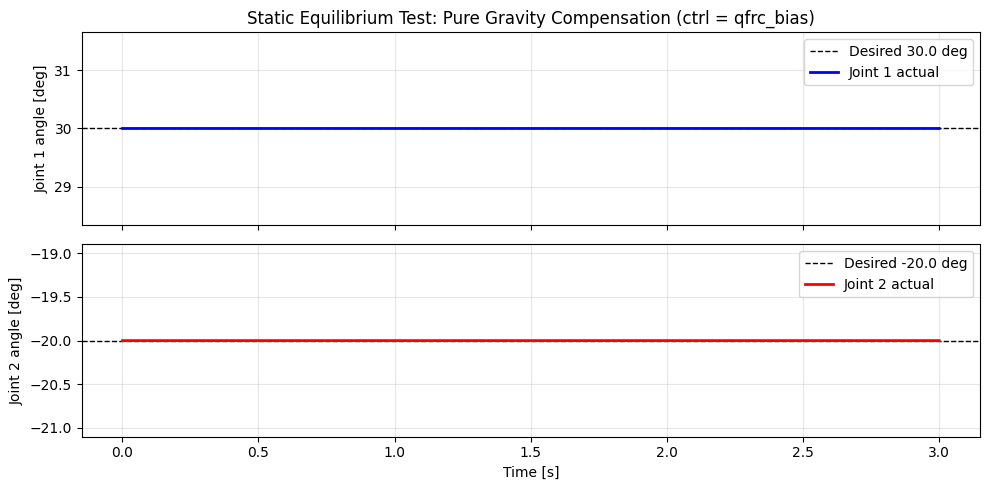

Joint 1 drift: 0.0000 degrees (should be < 0.01)
Joint 2 drift: 0.0000 degrees (should be < 0.01)
Gravity compensation validated: arm holds position.


In [23]:
# Test: pure gravity compensation at q=[30 deg, -20 deg]
q_hold = np.array([np.pi/6, -np.pi/9])   # ~30 deg, ~-20 deg
duration_eq = 3.0
n_steps_eq = int(duration_eq / model.opt.timestep)

t_eq   = np.zeros(n_steps_eq)
q1_eq  = np.zeros(n_steps_eq)
q2_eq  = np.zeros(n_steps_eq)

mujoco.mj_resetData(model, data)
data.qpos[:2] = q_hold

for i in range(n_steps_eq):
    # Pure gravity compensation: ctrl = qfrc_bias, no impedance term
    mujoco.mj_forward(model, data)
    data.ctrl[0] = data.qfrc_bias[0]
    data.ctrl[1] = data.qfrc_bias[1]
    mujoco.mj_step(model, data)
    t_eq[i]  = data.time
    q1_eq[i] = data.qpos[0]
    q2_eq[i] = data.qpos[1]

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].axhline(np.rad2deg(q_hold[0]), color='k', linestyle='--', linewidth=1,
                label=f'Desired {np.rad2deg(q_hold[0]):.1f} deg')
axes[0].plot(t_eq, np.rad2deg(q1_eq), 'b-', linewidth=2, label='Joint 1 actual')
axes[0].set_ylabel('Joint 1 angle [deg]')
axes[0].set_title('Static Equilibrium Test: Pure Gravity Compensation (ctrl = qfrc_bias)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(np.rad2deg(q_hold[1]), color='k', linestyle='--', linewidth=1,
                label=f'Desired {np.rad2deg(q_hold[1]):.1f} deg')
axes[1].plot(t_eq, np.rad2deg(q2_eq), 'r-', linewidth=2, label='Joint 2 actual')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Joint 2 angle [deg]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

drift_q1 = abs(np.rad2deg(q1_eq[-1]) - np.rad2deg(q_hold[0]))
drift_q2 = abs(np.rad2deg(q2_eq[-1]) - np.rad2deg(q_hold[1]))
print(f'Joint 1 drift: {drift_q1:.4f} degrees (should be < 0.01)')
print(f'Joint 2 drift: {drift_q2:.4f} degrees (should be < 0.01)')
print('Gravity compensation validated: arm holds position.')

## Experiment 1: Basic Step Response with Diagonal K, B

We start with **diagonal** stiffness and damping matrices:

$$\mathbf{K} = \begin{pmatrix} K_1 & 0 \\ 0 & K_2 \end{pmatrix} = \begin{pmatrix} 60 & 0 \\ 0 & 40 \end{pmatrix}\,\text{Nm/rad}$$

$$\mathbf{B} = \begin{pmatrix} B_1 & 0 \\ 0 & B_2 \end{pmatrix} = \begin{pmatrix} 12 & 0 \\ 0 & 8 \end{pmatrix}\,\text{Nms/rad}$$

Diagonal $\mathbf{K}$, $\mathbf{B}$ means each joint is controlled independently:
- Joint 1 has its own stiffness $K_1$ and damping $B_1$
- Joint 2 has its own stiffness $K_2$ and damping $B_2$
- No cross-joint coupling in the control law

**Step command:** Joint 1 from 0 to 45 deg, Joint 2 from 0 to -30 deg at $t = 0.5\,\text{s}$.

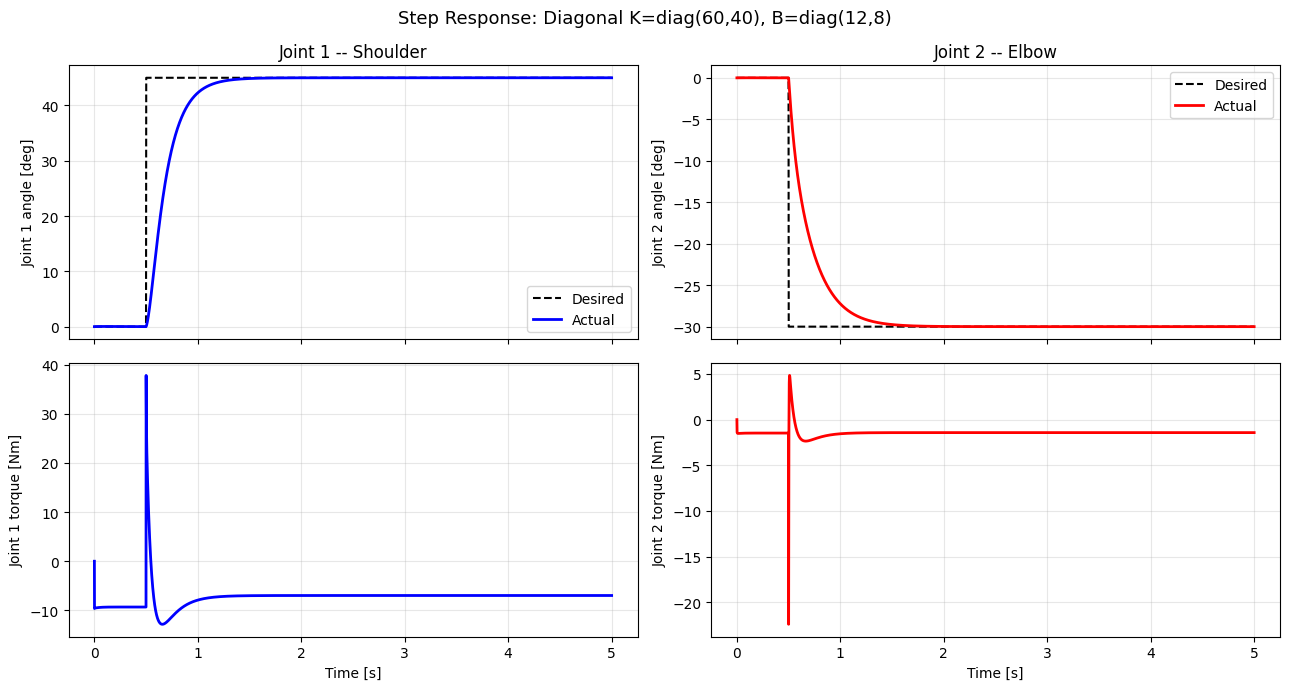

Joint 1 final: 45.00 deg (target: 45.0 deg)
Joint 2 final: -30.00 deg (target: -30.0 deg)


In [24]:
# Diagonal gains (independent per-joint control)
K_diag = np.diag([60.0, 40.0])   # stiffness [Nm/rad]
B_diag = np.diag([12.0, 8.0])    # damping   [Nms/rad]

# Step targets and timing
q_target = np.array([np.pi/4, -np.pi/6])   # [45 deg, -30 deg]
step_time = 0.5
duration_step = 5.0
n_steps_step = int(duration_step / model.opt.timestep)

# Pre-allocate recording arrays
t_step   = np.zeros(n_steps_step)
q_step   = np.zeros((n_steps_step, 2))
qd_step  = np.zeros((n_steps_step, 2))
tau_step = np.zeros((n_steps_step, 2))

mujoco.mj_resetData(model, data)

for i in range(n_steps_step):
    # Step command at t=0.5s
    q_d = q_target if data.time >= step_time else np.zeros(2)

    # Apply matrix impedance controller (sets data.ctrl) BEFORE mj_step
    arm_impedance_controller(model, data, q_d, np.zeros(2), K_diag, B_diag)

    mujoco.mj_step(model, data)

    t_step[i]   = data.time
    q_step[i]   = data.qpos[:2].copy()
    qd_step[i]  = q_d
    tau_step[i] = data.ctrl[:2].copy()

# 4-panel plot: joint angles and torques
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

axes[0, 0].plot(t_step, np.rad2deg(qd_step[:, 0]), 'k--', linewidth=1.5, label='Desired')
axes[0, 0].plot(t_step, np.rad2deg(q_step[:, 0]),  'b-',  linewidth=2,   label='Actual')
axes[0, 0].set_ylabel('Joint 1 angle [deg]')
axes[0, 0].set_title('Joint 1 -- Shoulder')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_step, np.rad2deg(qd_step[:, 1]), 'k--', linewidth=1.5, label='Desired')
axes[0, 1].plot(t_step, np.rad2deg(q_step[:, 1]),  'r-',  linewidth=2,   label='Actual')
axes[0, 1].set_ylabel('Joint 2 angle [deg]')
axes[0, 1].set_title('Joint 2 -- Elbow')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(t_step, tau_step[:, 0], 'b-', linewidth=2)
axes[1, 0].set_xlabel('Time [s]')
axes[1, 0].set_ylabel('Joint 1 torque [Nm]')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_step, tau_step[:, 1], 'r-', linewidth=2)
axes[1, 1].set_xlabel('Time [s]')
axes[1, 1].set_ylabel('Joint 2 torque [Nm]')
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Step Response: Diagonal K=diag(60,40), B=diag(12,8)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Joint 1 final: {np.rad2deg(q_step[-1, 0]):.2f} deg (target: {np.rad2deg(q_target[0]):.1f} deg)')
print(f'Joint 2 final: {np.rad2deg(q_step[-1, 1]):.2f} deg (target: {np.rad2deg(q_target[1]):.1f} deg)')

## The Coupling Demo 
Here is the central experiment of this notebook.

**Setup:** We command joint 1 to follow a 1 Hz sinusoidal trajectory (0 to 60 deg oscillation). Joint 2's desired position is held at 0 deg (no motion desired).

**Controller:** Diagonal $\mathbf{K}$, $\mathbf{B}$ -- each joint controlled independently. Joint 2 has $K_2 = 20\,\text{Nm/rad}$ (deliberately low to make coupling visible).

**Prediction from Notebook 2 logic:** If joints are independent, moving joint 1 should have no effect on joint 2. Joint 2 should stay at 0 deg.

**What actually happens:** Joint 2 drifts. Watch the plot.

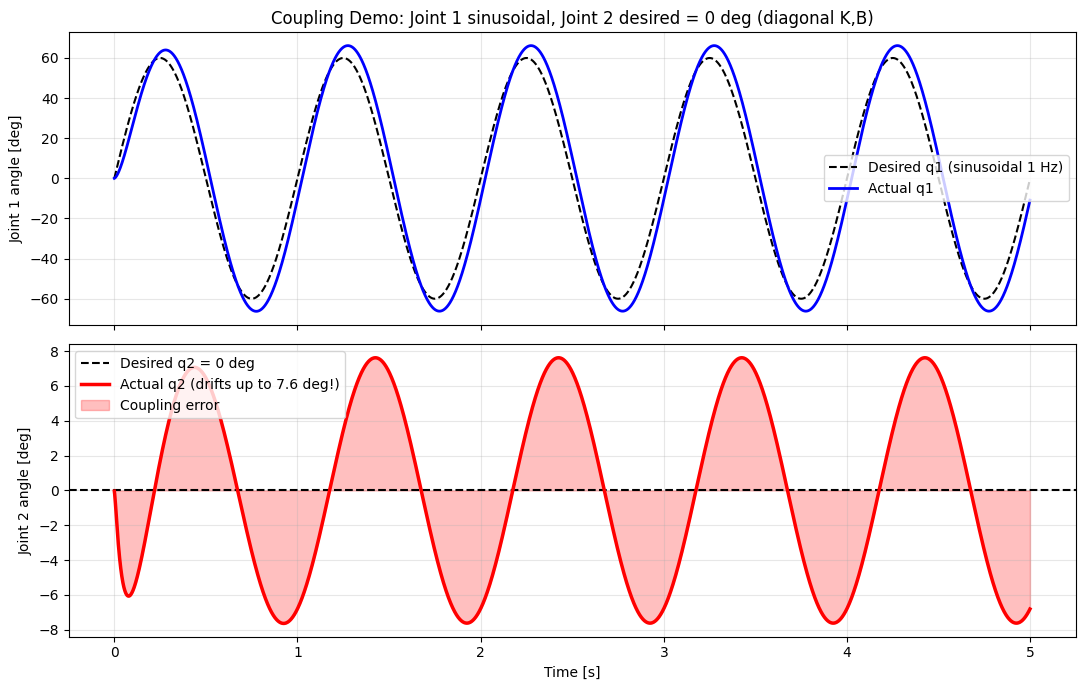

Maximum joint 2 drift: 7.64 degrees

Joint 2 was commanded to stay at 0 deg but drifted.
The diagonal K,B controller treats each joint independently,
but the physics are coupled through the mass matrix M(q).


In [25]:
# Coupling demo: joint 1 sinusoidal, joint 2 hold at zero
# Deliberately low K2 to exaggerate the coupling effect
K_coupling = np.diag([60.0, 20.0])   # K2=20 is low -- coupling drift is visible
B_coupling = np.diag([12.0,  4.0])   # B2 scaled to match low K2

amp_j1  = np.deg2rad(60.0)   # 60 deg amplitude for joint 1
freq_j1 = 1.0                # 1 Hz
duration_coup = 5.0
n_coup = int(duration_coup / model.opt.timestep)

t_coup   = np.zeros(n_coup)
q1_coup  = np.zeros(n_coup)
q2_coup  = np.zeros(n_coup)
q1d_coup = np.zeros(n_coup)

mujoco.mj_resetData(model, data)

for i in range(n_coup):
    t_now = data.time
    # Joint 1: sinusoidal trajectory
    q1_d  = amp_j1 * np.sin(2 * np.pi * freq_j1 * t_now)
    dq1_d = amp_j1 * 2 * np.pi * freq_j1 * np.cos(2 * np.pi * freq_j1 * t_now)
    # Joint 2: hold at zero
    q_d_vec  = np.array([q1_d, 0.0])
    dq_d_vec = np.array([dq1_d, 0.0])

    arm_impedance_controller(model, data, q_d_vec, dq_d_vec, K_coupling, B_coupling)
    mujoco.mj_step(model, data)

    t_coup[i]   = t_now
    q1_coup[i]  = data.qpos[0]
    q2_coup[i]  = data.qpos[1]
    q1d_coup[i] = q1_d

max_j2_drift = np.max(np.abs(np.rad2deg(q2_coup)))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(t_coup, np.rad2deg(q1d_coup), 'k--', linewidth=1.5,
             label='Desired q1 (sinusoidal 1 Hz)')
axes[0].plot(t_coup, np.rad2deg(q1_coup),  'b-',  linewidth=2,   label='Actual q1')
axes[0].set_ylabel('Joint 1 angle [deg]')
axes[0].set_title('Coupling Demo: Joint 1 sinusoidal, Joint 2 desired = 0 deg (diagonal K,B)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0, color='k', linestyle='--', linewidth=1.5, label='Desired q2 = 0 deg')
axes[1].plot(t_coup, np.rad2deg(q2_coup), 'r-', linewidth=2.5,
             label=f'Actual q2 (drifts up to {max_j2_drift:.1f} deg!)')
axes[1].fill_between(t_coup, np.rad2deg(q2_coup), 0,
                     alpha=0.25, color='red', label='Coupling error')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Joint 2 angle [deg]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Maximum joint 2 drift: {max_j2_drift:.2f} degrees')
print()
print('Joint 2 was commanded to stay at 0 deg but drifted.')
print('The diagonal K,B controller treats each joint independently,')
print('but the physics are coupled through the mass matrix M(q).')

## Why Diagonal K, B Fails -- Physical Explanation

Joint 2 drifted even though we commanded it to stay at 0 deg. Why?

**The physics:** The equations of motion for joint 2 include an inertial coupling term:

$$M_{22} \ddot{q}_2 + \underbrace{M_{21} \ddot{q}_1}_{\text{coupling}} + \text{Coriolis} + g_2 = \tau_2$$

When joint 1 accelerates rapidly ($\ddot{q}_1$ is large), the coupling term $M_{21} \ddot{q}_1$ creates a force on joint 2.

**What the diagonal controller provides:** $\tau_2 = K_2(0 - q_2) + B_2(0 - \dot{q}_2) + \tau_{g2}$

The impedance term resists the coupling force, but only through position and velocity feedback (like a spring-damper). Low $K_2 = 20\,\text{Nm/rad}$ means the spring is soft -- joint 2 deflects before the spring restoring force balances the coupling disturbance.

**Gravity + Coriolis coupling:** Additionally, `qfrc_bias[1]` includes Coriolis terms that depend on $\dot{q}_1$. These are also coupling terms that a diagonal controller cannot cancel.

**The fix:** We need cross-joint terms in $\mathbf{K}$ and $\mathbf{B}$ that allow the controller to *anticipate* coupling -- or equivalently, that let joint 2's controller respond to joint 1's error.

## Full Matrix K, B -- Eliminating Coupling Drift

We introduce off-diagonal terms in $\mathbf{K}$ and $\mathbf{B}$:

$$\mathbf{K}_{\text{full}} = \begin{pmatrix} 60 & 15 \\ 15 & 20 \end{pmatrix}\,\text{Nm/rad}$$

$$\mathbf{B}_{\text{full}} = \begin{pmatrix} 12 & 3 \\ 3 & 4 \end{pmatrix}\,\text{Nms/rad}$$

**Interpretation of off-diagonal terms:**
- $K_{12} = 15$: when joint 1 deviates from its target, also apply a restoring torque to joint 2
- This effectively makes the controller "aware" of cross-joint disturbances

**Why symmetric positive-definite?**
- Symmetric $\mathbf{K}$ and $\mathbf{B}$ guarantee energy dissipation (no energy injected by controller asymmetry)
- Positive definite ensures stability (all eigenvalues > 0 means always resists displacement)
- Check: $\lambda_{\min}(\mathbf{K}_{\text{full}}) > 0$ -- both eigenvalues must be positive

We run the **exact same coupling trajectory** and compare the result.

K_full eigenvalues: [15. 65.]  (all positive: True)
B_full eigenvalues: [ 3. 13.]  (all positive: True)



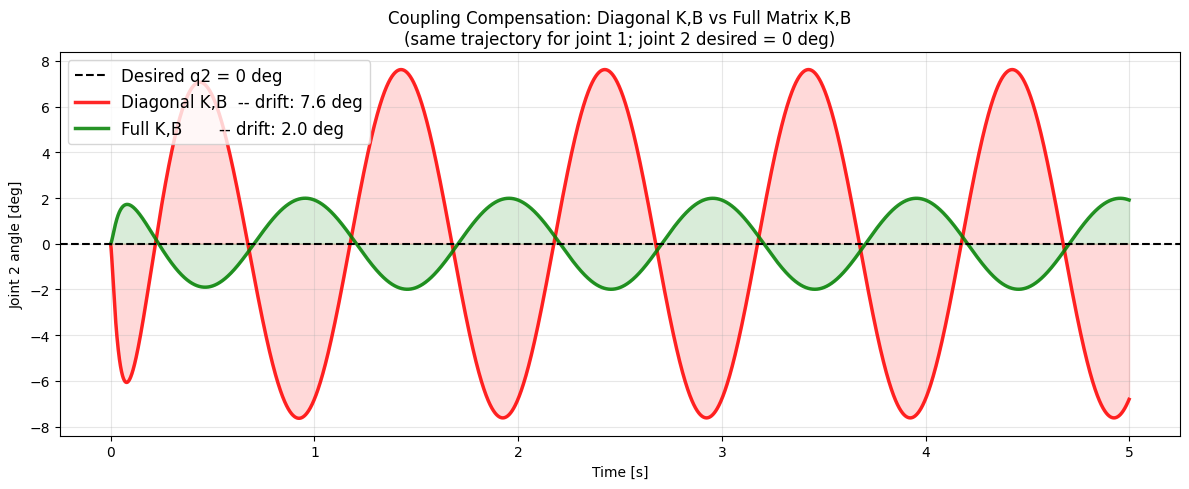

Diagonal K,B max joint 2 drift:  7.64 deg
Full K,B max joint 2 drift:      1.99 deg
Drift reduction with full K,B:   73.9%


In [26]:
# Full (non-diagonal) stiffness and damping matrices
K_full = np.array([[60.0, 15.0],
                   [15.0, 20.0]])   # symmetric positive-definite
B_full = np.array([[12.0,  3.0],
                   [ 3.0,  4.0]])   # symmetric positive-definite

# Verify positive definiteness (all eigenvalues must be > 0)
eig_K = np.linalg.eigvalsh(K_full)
eig_B = np.linalg.eigvalsh(B_full)
print(f'K_full eigenvalues: {eig_K}  (all positive: {np.all(eig_K > 0)})')
print(f'B_full eigenvalues: {eig_B}  (all positive: {np.all(eig_B > 0)})')
print()

# Run same coupling demo with full matrix K,B
t_fix  = np.zeros(n_coup)
q2_fix = np.zeros(n_coup)
q1_fix = np.zeros(n_coup)

mujoco.mj_resetData(model, data)

for i in range(n_coup):
    t_now = data.time
    q1_d  = amp_j1 * np.sin(2 * np.pi * freq_j1 * t_now)
    dq1_d = amp_j1 * 2 * np.pi * freq_j1 * np.cos(2 * np.pi * freq_j1 * t_now)
    q_d_vec  = np.array([q1_d, 0.0])
    dq_d_vec = np.array([dq1_d, 0.0])

    arm_impedance_controller(model, data, q_d_vec, dq_d_vec, K_full, B_full)
    mujoco.mj_step(model, data)

    t_fix[i]  = t_now
    q2_fix[i] = data.qpos[1]
    q1_fix[i] = data.qpos[0]

max_j2_drift_fix = np.max(np.abs(np.rad2deg(q2_fix)))

# Side-by-side comparison: joint 2 drift with diagonal vs full K,B
fig, ax = plt.subplots(figsize=(12, 5))
ax.axhline(0, color='k', linestyle='--', linewidth=1.5, label='Desired q2 = 0 deg', zorder=5)
ax.plot(t_coup, np.rad2deg(q2_coup), 'r-', linewidth=2.5,
        label=f'Diagonal K,B  -- drift: {max_j2_drift:.1f} deg', alpha=0.85)
ax.plot(t_fix,  np.rad2deg(q2_fix),  'g-', linewidth=2.5,
        label=f'Full K,B       -- drift: {max_j2_drift_fix:.1f} deg', alpha=0.85)
ax.fill_between(t_coup, np.rad2deg(q2_coup), 0, alpha=0.15, color='red')
ax.fill_between(t_fix,  np.rad2deg(q2_fix),  0, alpha=0.15, color='green')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Joint 2 angle [deg]')
ax.set_title('Coupling Compensation: Diagonal K,B vs Full Matrix K,B\n'
             '(same trajectory for joint 1; joint 2 desired = 0 deg)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

reduction = (1 - max_j2_drift_fix / max_j2_drift) * 100
print(f'Diagonal K,B max joint 2 drift:  {max_j2_drift:.2f} deg')
print(f'Full K,B max joint 2 drift:      {max_j2_drift_fix:.2f} deg')
print(f'Drift reduction with full K,B:   {reduction:.1f}%')

## Parameter Sweep: How K1 and K2 Affect Each Other

Because the joints are dynamically coupled, the stiffness in one joint affects the tracking behavior of the other. Let's quantify this.

**Experiment:** Run the sinusoidal coupling demo for different combinations of $K_1$ and $K_2$ (diagonal gains only). Measure the maximum joint 2 drift (which should be held at 0 deg).

**Prediction:**
- Higher $K_2$ should reduce joint 2 drift (stiffer restoring force)
- Higher $K_1$ should *increase* joint 2 drift (joint 1 tracks better -- larger accelerations -- more coupling force)

This reveals the coupling: you cannot tune one joint in isolation.

Parameter sweep: max joint 2 drift [deg] as function of K1, K2
(joint 1 sinusoidal 1 Hz, joint 2 desired = 0 deg)



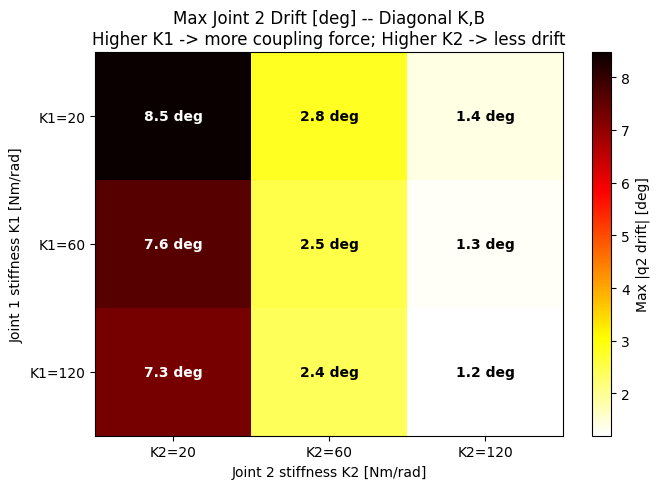

Key observations:
  - Moving right (higher K2): drift decreases -- stiffer joint 2 resists coupling
  - Moving down  (higher K1): drift increases -- joint 1 tracks harder -> more coupling
  - You cannot tune K1 and K2 in isolation: they interact through M(q)


In [27]:
def run_coupling_demo(model, K1, K2):
    """Run coupling demo with diagonal K=[K1,K2], return max abs joint 2 drift [deg]."""
    data_local = mujoco.MjData(model)
    K_local = np.diag([K1, K2])
    B_local = np.diag([K1 / 5.0, K2 / 5.0])   # B = K/5 as simple rule of thumb
    n = int(5.0 / model.opt.timestep)
    max_drift = 0.0

    mujoco.mj_resetData(model, data_local)
    for _ in range(n):
        t_now = data_local.time
        q1_d  = amp_j1 * np.sin(2 * np.pi * freq_j1 * t_now)
        dq1_d = amp_j1 * 2 * np.pi * freq_j1 * np.cos(2 * np.pi * freq_j1 * t_now)
        arm_impedance_controller(model, data_local,
                                  np.array([q1_d, 0.0]),
                                  np.array([dq1_d, 0.0]),
                                  K_local, B_local)
        mujoco.mj_step(model, data_local)
        drift = abs(np.rad2deg(data_local.qpos[1]))
        if drift > max_drift:
            max_drift = drift
    return max_drift


K_sweep_values = [20, 60, 120]
sweep_results = np.zeros((len(K_sweep_values), len(K_sweep_values)))

print('Parameter sweep: max joint 2 drift [deg] as function of K1, K2')
print('(joint 1 sinusoidal 1 Hz, joint 2 desired = 0 deg)')
print()

for i, k1 in enumerate(K_sweep_values):
    for j, k2 in enumerate(K_sweep_values):
        sweep_results[i, j] = run_coupling_demo(model, k1, k2)

# Plot as heatmap
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(sweep_results, aspect='auto', origin='upper', cmap='hot_r')
ax.set_xticks(range(len(K_sweep_values)))
ax.set_yticks(range(len(K_sweep_values)))
ax.set_xticklabels([f'K2={k}' for k in K_sweep_values])
ax.set_yticklabels([f'K1={k}' for k in K_sweep_values])
ax.set_xlabel('Joint 2 stiffness K2 [Nm/rad]')
ax.set_ylabel('Joint 1 stiffness K1 [Nm/rad]')
ax.set_title('Max Joint 2 Drift [deg] -- Diagonal K,B\n'
             'Higher K1 -> more coupling force; Higher K2 -> less drift')
plt.colorbar(im, ax=ax, label='Max |q2 drift| [deg]')
for i in range(len(K_sweep_values)):
    for j in range(len(K_sweep_values)):
        ax.text(j, i, f'{sweep_results[i, j]:.1f} deg', ha='center', va='center',
                color='white' if sweep_results[i, j] > sweep_results.max() * 0.5 else 'black',
                fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key observations:')
print('  - Moving right (higher K2): drift decreases -- stiffer joint 2 resists coupling')
print('  - Moving down  (higher K1): drift increases -- joint 1 tracks harder -> more coupling')
print('  - You cannot tune K1 and K2 in isolation: they interact through M(q)')

## Inline Video

We render the coupling demo as a side-by-side inline video using `mujoco.Renderer` and `mediapy`.
The left panel shows diagonal $K$, $B$ (joint 2 drifts); the right shows full matrix $K$, $B$ (joint 2 holds).

In [28]:
try:
    fps = 30
    video_duration = 4.0
    render_every = max(1, int(1.0 / (fps * model.opt.timestep)))
    n_video = int(video_duration / model.opt.timestep)
    renderer = mujoco.Renderer(model, height=300, width=400)

    def render_coupling_sim(K_mat, B_mat):
        frames = []
        data_vid = mujoco.MjData(model)
        mujoco.mj_resetData(model, data_vid)
        for step_i in range(n_video):
            t_now = data_vid.time
            q1_d  = amp_j1 * np.sin(2 * np.pi * freq_j1 * t_now)
            dq1_d = amp_j1 * 2 * np.pi * freq_j1 * np.cos(2 * np.pi * freq_j1 * t_now)
            arm_impedance_controller(model, data_vid,
                                     np.array([q1_d, 0.0]),
                                     np.array([dq1_d, 0.0]),
                                     K_mat, B_mat)
            mujoco.mj_step(model, data_vid)
            if step_i % render_every == 0:
                renderer.update_scene(data_vid)
                frames.append(renderer.render())
        return frames

    frames_diag_vid = render_coupling_sim(K_coupling, B_coupling)
    frames_full_vid = render_coupling_sim(K_full, B_full)
    renderer.close()

    # Stack left (diagonal) and right (full) side by side
    combined_frames = [np.concatenate([f1, f2], axis=1)
                       for f1, f2 in zip(frames_diag_vid, frames_full_vid)]
  
    mediapy.show_video(combined_frames, fps=fps)
    print('Left: diagonal K,B (joint 2 drifts)  |  Right: full K,B (joint 2 holds)')
  
except Exception as e:
    print(f'Video rendering skipped (headless or renderer unavailable): {e}')

This browser does not support the video tag.


Left: diagonal K,B (joint 2 drifts)  |  Right: full K,B (joint 2 holds)


## Summary and What's Next

### Key Takeaways

1. **The matrix impedance law is the same equation as the scalar law** -- scalars become vectors and matrices. The `@` operator in Python implements the matrix-vector product that the math requires.

2. **The mass matrix $\mathbf{M}(\mathbf{q})$ has off-diagonal terms** that reveal dynamic coupling between joints. For our asymmetric arm, $M_{12} \approx 22\%$ of $M_{11}$ -- substantial enough to produce visible drift.

3. **Diagonal $\mathbf{K}$, $\mathbf{B}$ fails for coupled dynamics.** Each joint is controlled independently, but the physics are coupled. Coupling forces from joint 1 motion appear as disturbances to joint 2 that the diagonal controller cannot anticipate.

4. **Full symmetric positive-definite $\mathbf{K}$, $\mathbf{B}$ eliminates coupling drift.** Off-diagonal gains allow the controller to respond to cross-joint errors, compensating for the coupling.

5. **Stiffness gains interact.** Higher $K_1$ improves joint 1 tracking but increases coupling forces on joint 2. You cannot tune one joint in isolation -- the gains are coupled through the physics.

### From Joint Space to Task Space

In this notebook, we specified stiffness **in joint coordinates** -- $K_1$ controls joint 1, $K_2$ controls joint 2. The end-effector position was a consequence.

**The question Notebook 4 answers:** What if we want to say *"I want 500 N/m stiffness in the X direction and 200 N/m in the Z direction"*?

We need to express the impedance law in Cartesian space and then map forces back to joint torques. The mapping is the **Jacobian transpose**:

$$\boldsymbol{\tau} = \mathbf{J}^T(\mathbf{q}) \, \mathbf{F}_{\text{cart}}$$

where $\mathbf{F}_{\text{cart}} = \mathbf{K}_{\text{cart}}(\mathbf{x}_d - \mathbf{x}) + \mathbf{B}_{\text{cart}}(\dot{\mathbf{x}}_d - \dot{\mathbf{x}})$ is the desired Cartesian restoring force.

MuJoCo computes $\mathbf{J}(\mathbf{q})$ for us via `mj_jacSite` -- using the `ee` site we defined in the MJCF model.